In [1]:
%%bash
git clone https://github.com/DIDSR/VICTRE_PIPELINE.git
cd VICTRE_PIPELINE

Cloning into 'VICTRE_PIPELINE'...


In [3]:
%%bash
cd VICTRE_PIPELINE
pip install -r requirements.txt --dry-run

Would install cloudpickle-3.1.2 joblib-1.6.0 narwhals-2.25.0 scikit-learn-1.9.0 threadpoolctl-3.6.0


In [4]:
%%bash
micromamba install -n science scikit-learn -c conda-forge -y


Pinned packages:

  - python=3.12


Transaction

  Prefix: /Users/arindambose/micromamba/envs/science

  Updating specs:

   - scikit-learn


  Package          Version  Build               Channel          Size
───────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────

  + cloudpickle      3.1.2  pyhcf101f3_1        conda-forge      27kB
  + joblib           1.6.0  pyhcf101f3_0        conda-forge     229kB
  + narwhals        2.25.0  pyhcf101f3_0        conda-forge     294kB
  + scikit-learn     1.9.0  np2py312he5ca3e3_0  conda-forge       9MB
  + threadpoolctl    3.6.0  pyhecae5ae_0        conda-forge      24kB

  Summary:

  Install: 5 packages

  Total download: 10MB

───────────────────────────────────────────────────────────────────────



Transaction starting
Linking narwhals-2.25.0-pyhcf101f3_0
Linking threadpoolctl-3.6.0-pyhecae5ae_0
Linking cloudpickle-3.1.2-pyhcf101f3_1
Linking 

In [6]:
%%bash
cd VICTRE_PIPELINE
pip install -r requirements.txt --dry-run

Loaded via SimpleITK. Matrix Shape: (258, 539, 331)


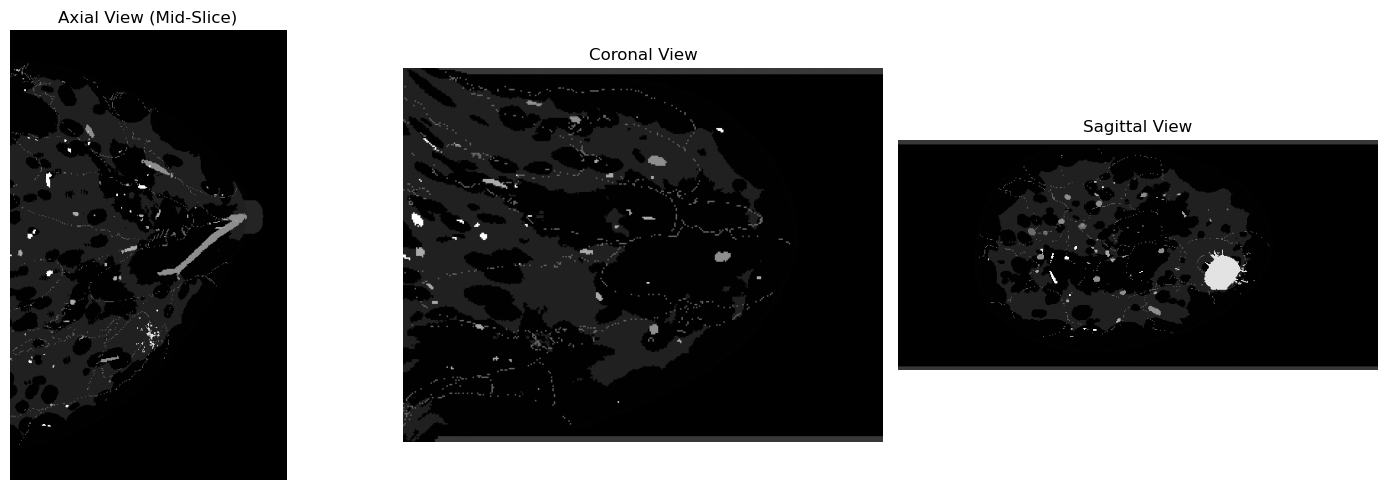

In [7]:
## Visualise the 3D phantom slices

import os
import gzip
import numpy as np
import matplotlib.pyplot as plt

# Path to the pre-generated phantom
MHD_PATH = os.path.expanduser("~/aesculytics/VICTRE_PIPELINE/phantoms/pcl_1.mhd")
RAW_GZ_PATH = os.path.expanduser("~/aesculytics/VICTRE_PIPELINE/phantoms/pcl_1.raw.gz")

def load_and_plot_phantom():
    try:
        import SimpleITK as sitk
        img = sitk.ReadImage(MHD_PATH)
        data = sitk.GetArrayFromImage(img)
        print(f"Loaded via SimpleITK. Matrix Shape: {data.shape}")
    except ImportError:
        # Direct raw extraction fallback
        with gzip.open(RAW_GZ_PATH, 'rb') as f:
            data = np.frombuffer(f.read(), dtype=np.uint8)
        # Reshape to standard 3D dimensions (adjust if custom dimensions were used)
        print(f"Loaded raw bytes. Total size: {data.size} voxels")
        # Visualizing flattened mid-section byte sample
        data = data.reshape((-1, 512, 512)) if data.size % (512*512) == 0 else data

    # Plot 3 central slices (Coronal, Sagittal, Axial)
    if len(data.shape) == 3:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(data[data.shape[0] // 2, :, :], cmap='gray')
        axes[0].set_title("Axial View (Mid-Slice)")
        
        axes[1].imshow(data[:, data.shape[1] // 2, :], cmap='gray')
        axes[1].set_title("Coronal View")
        
        axes[2].imshow(data[:, :, data.shape[2] // 2], cmap='gray')
        axes[2].set_title("Sagittal View")
        
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

load_and_plot_phantom()

In [8]:
# Now inspect the lesions
# Path to lesion location file
LOC_PATH = os.path.expanduser("~/aesculytics/VICTRE_PIPELINE/phantoms/pcl_1.loc")

if os.path.exists(LOC_PATH):
    print("--- Lesion Location Metadata ---")
    with open(LOC_PATH, "r") as f:
        loc_data = f.read()
    print(loc_data)
else:
    print(f"Location file not found at: {LOC_PATH}")

--- Lesion Location Metadata ---
125 138 244 2
170 79 123 2
103 89 408 2
157 125 183 2



In [11]:
def plot_lesion_roi(phantom_3d, center_x, center_y, center_z, window_size=60):
    """Crops and visualizes a bounding box around the inserted lesion."""
    x_min, x_max = max(0, center_x - window_size), center_x + window_size
    y_min, y_max = max(0, center_y - window_size), center_y + window_size
    
    roi = phantom_3d[center_z, y_min:y_max, x_min:x_max]
    
    plt.figure(figsize=(6, 6))
    plt.imshow(roi, cmap='bone')
    plt.title(f"Extracted Lesion ROI Patch (Z-Slice {center_z})")
    plt.colorbar(label="Voxel Tissue ID")
    plt.axis('off')
    plt.show()

# Example usage with arbitrary mid-point coordinates (adjust based on .loc output)
# plot_lesion_roi(data, center_x=256, center_y=256, center_z=100)

In [12]:
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [15]:
# 1. Read the MHD metadata / RAW volumes directly
# SimpleITK reads .mhd headers automatically and loads the paired .raw files
sitk_absent = sitk.ReadImage("VICTRE_PIPELINE/phantoms/pc_1.mhd")
sitk_present = sitk.ReadImage("VICTRE_PIPELINE//phantoms/pcl_1.mhd")

In [16]:
# 2. Export to NIfTI for 3D Slicer
os.makedirs("VICTRE_PIPELINE/results", exist_ok=True)
sitk.WriteImage(sitk_absent, "VICTRE_PIPELINE/results/phantom_absent.nii.gz")
sitk.WriteImage(sitk_present, "VICTRE_PIPELINE/results/phantom_present.nii.gz")
print("Exported NIfTI files to VICTRE_PIPELINE/results/ for 3D Slicer viewing!")

Exported NIfTI files to VICTRE_PIPELINE/results/ for 3D Slicer viewing!


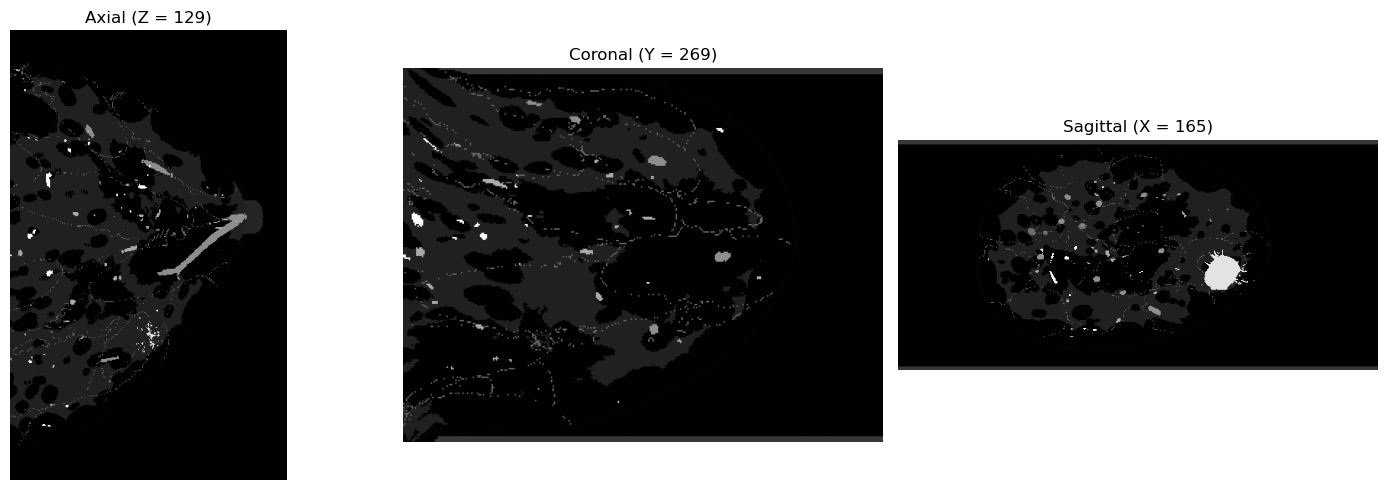

interactive(children=(IntSlider(value=129, description='z', max=257), IntSlider(value=269, description='y', ma…

In [18]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
from ipywidgets import interact

# 1. Read the NIfTI file back into memory
image_sitk = sitk.ReadImage("VICTRE_PIPELINE/results/phantom_present.nii.gz")
vol_data = sitk.GetArrayFromImage(image_sitk)  # Returns shape (Z, Y, X)

# 2. Create an interactive slider widget
@interact(
    z=(0, vol_data.shape[0] - 1),
    y=(0, vol_data.shape[1] - 1),
    x=(0, vol_data.shape[2] - 1)
)
def explore_phantom(z=vol_data.shape[0]//2, y=vol_data.shape[1]//2, x=vol_data.shape[2]//2):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Axial View (Z slice)
    axes[0].imshow(vol_data[z, :, :], cmap='gray')
    axes[0].set_title(f"Axial (Z = {z})")
    axes[0].axis('off')
    
    # Coronal View (Y slice)
    axes[1].imshow(vol_data[:, y, :], cmap='gray')
    axes[1].set_title(f"Coronal (Y = {y})")
    axes[1].axis('off')
    
    # Sagittal View (X slice)
    axes[2].imshow(vol_data[:, :, x], cmap='gray')
    axes[2].set_title(f"Sagittal (X = {x})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

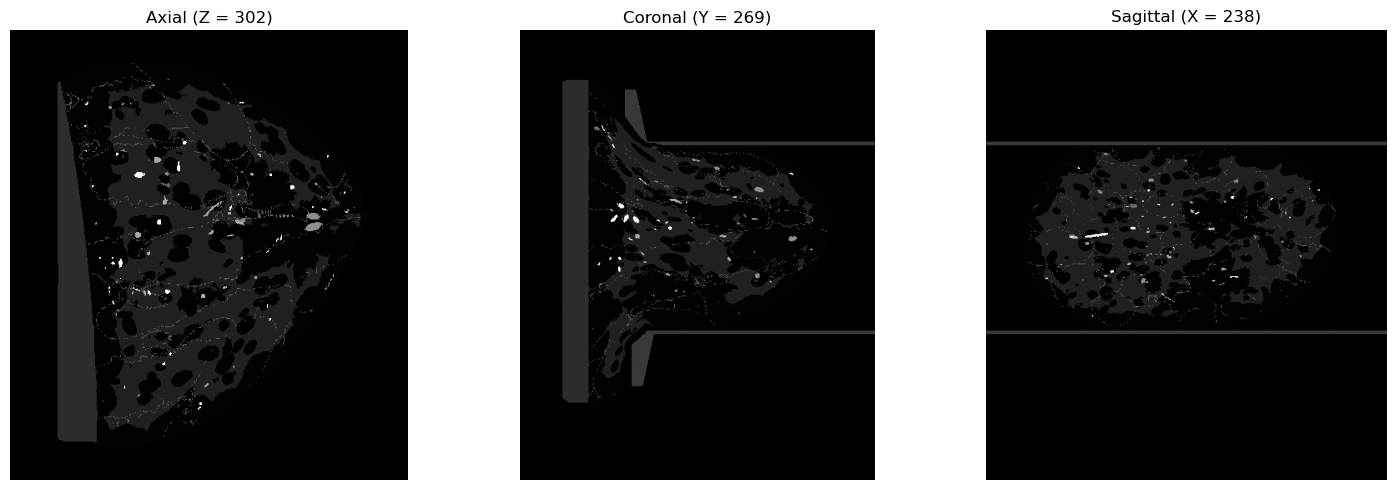

interactive(children=(IntSlider(value=302, description='z', max=604), IntSlider(value=269, description='y', ma…

In [19]:
# 1. Read the NIfTI file back into memory
image_sitk2 = sitk.ReadImage("VICTRE_PIPELINE/results/phantom_absent.nii.gz")
vol_data2 = sitk.GetArrayFromImage(image_sitk2)  # Returns shape (Z, Y, X)

# 2. Create an interactive slider widget
@interact(
    z=(0, vol_data2.shape[0] - 1),
    y=(0, vol_data2.shape[1] - 1),
    x=(0, vol_data2.shape[2] - 1)
)
def explore_phantom(z=vol_data2.shape[0]//2, y=vol_data2.shape[1]//2, x=vol_data2.shape[2]//2):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Axial View (Z slice)
    axes[0].imshow(vol_data2[z, :, :], cmap='gray')
    axes[0].set_title(f"Axial (Z = {z})")
    axes[0].axis('off')
    
    # Coronal View (Y slice)
    axes[1].imshow(vol_data2[:, y, :], cmap='gray')
    axes[1].set_title(f"Coronal (Y = {y})")
    axes[1].axis('off')
    
    # Sagittal View (X slice)
    axes[2].imshow(vol_data2[:, :, x], cmap='gray')
    axes[2].set_title(f"Sagittal (X = {x})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [20]:
# 3. Convert to NumPy for ROI Extraction
vol_absent = sitk.GetArrayFromImage(sitk_absent)   # Shape: (Z, Y, X)
vol_present = sitk.GetArrayFromImage(sitk_present)

In [21]:
# 4. Extract ROIs (Read lesion coordinates from pcl_1.loc or target center)
slice_idx = vol_present.shape[0] // 2
roi_size = 32
half = roi_size // 2

In [24]:
# Sample Lesion-Absent ROIs (g0)
n_samples = 100
g0_list = []
np.random.seed(42)
for _ in range(n_samples):
    zy = np.random.randint(half + 10, vol_absent.shape[1] - half - 10)
    zx = np.random.randint(half + 10, vol_absent.shape[2] - half - 10)
    patch = vol_absent[slice_idx, zy-half:zy+half, zx-half:zx+half].astype(np.float32)
    patch += np.random.normal(0, 1.0, patch.shape)
    g0_list.append(patch)

In [23]:
g0_list

[array([[ 0.54374313, -0.61542976, -1.1978065 , ..., -0.0331934 ,
         -0.74907655, -0.778382  ],
        [ 0.9488429 ,  1.5808506 , -0.36817095, ..., -0.9067207 ,
          0.4760426 ,  1.3036612 ],
        [ 0.21158701,  0.59704465, -0.8963352 , ...,  0.8966304 ,
         -0.610322  , -0.3161659 ],
        ...,
        [ 1.5673078 ,  0.34310907, -0.7820957 , ..., -1.224935  ,
          0.08895227,  1.1659137 ],
        [-0.54260486,  0.87710196,  0.46372387, ...,  0.31642607,
          0.44465518, -0.99535537],
        [ 0.89073807, -1.7177936 ,  0.29645893, ...,  1.5236841 ,
          0.3719599 , -0.17193168]], shape=(32, 32), dtype=float32),
 array([[ 1.2651973 ,  0.5593592 , -0.33541214, ..., -0.37017062,
         -0.33662271,  0.35175467],
        [-0.09175932,  0.50278974,  0.383544  , ..., -0.7359519 ,
         -0.19993985, -0.8475235 ],
        [ 1.542256  ,  1.8044971 , -0.6857376 , ...,  1.7911438 ,
          0.17390804,  1.0894367 ],
        ...,
        [ 0.32439998, -

In [25]:
# Sample Lesion-Present ROIs (g1)
center_y, center_x = vol_present.shape[1] // 2, vol_present.shape[2] // 2
g1_list = []
for _ in range(n_samples):
    patch = vol_present[slice_idx, center_y-half:center_y+half, center_x-half:center_x+half].astype(np.float32)
    patch += np.random.normal(0, 1.0, patch.shape)
    g1_list.append(patch)

g0_flat = np.array(g0_list).reshape(n_samples, -1)
g1_flat = np.array(g1_list).reshape(n_samples, -1)

In [42]:
g1_flat

array([[29, 29, 29, ...,  1, 29, 29],
       [29, 29, 29, ...,  1, 29, 29],
       [29, 29, 29, ...,  1, 29, 29],
       ...,
       [29, 29, 29, ...,  1, 29, 29],
       [29, 29, 29, ...,  1, 29, 29],
       [29, 29, 29, ...,  1, 29, 29]], shape=(100, 1024), dtype=uint8)

In [46]:
import numpy as np
import SimpleITK as sitk
from scipy.special import eval_laguerre
from scipy.integrate import trapezoid
from sklearn.metrics import roc_curve

# =====================================================================
# 1. LAGUERRE-GAUSS CHANNEL GENERATOR MATRIX (U)
# =====================================================================
def generate_laguerre_gauss_channels(roi_size=32, num_channels=5, channel_width=8.0):
    center = (roi_size - 1) / 2.0
    y, x = np.ogrid[:roi_size, :roi_size]
    r_sq = (x - center)**2 + (y - center)**2

    channels = []
    for n in range(num_channels):
        x_val = (2 * np.pi * r_sq) / (channel_width**2)
        gaussian_envelope = np.exp(-np.pi * r_sq / (channel_width**2))
        laguerre_poly = eval_laguerre(n, x_val)
        
        u_n = (np.sqrt(2) / channel_width) * gaussian_envelope * laguerre_poly
        u_n = u_n / np.linalg.norm(u_n)
        channels.append(u_n.flatten())

    return np.column_stack(channels)

# =====================================================================
# 2. READ VOLUMES & EXTRACT PAIRED PATCHES ACROSS MULTIPLE SLICES
# =====================================================================
# vol_absent = sitk.GetArrayFromImage(sitk.ReadImage("pc_1.mhd")).astype(np.float64)
# vol_present = sitk.GetArrayFromImage(sitk.ReadImage("pcl_1.mhd")).astype(np.float64)

patch_size = 32
half_p = patch_size // 2

# Target lesion center (y, x)
mass_y, mass_x = 250, 200

g0_list = []
g1_list = []

# Sample across Z-slices (e.g., slices 40 to 80) to get independent noise realisations
slices = np.linspace(40, 80, 100, dtype=int)

for sz in slices:
    patch_absent = vol_absent[sz, mass_y-half_p:mass_y+half_p, mass_x-half_p:mass_x+half_p]
    patch_present = vol_present[sz, mass_y-half_p:mass_y+half_p, mass_x-half_p:mass_x+half_p]
    
    if patch_absent.shape == (32, 32) and patch_present.shape == (32, 32):
        # Subtract mean of each patch to zero-out constant background DC offsets
        patch_absent = patch_absent - np.mean(patch_absent)
        patch_present = patch_present - np.mean(patch_present)
        
        g0_list.append(patch_absent)
        g1_list.append(patch_present)

g0_array = np.array(g0_list)
g1_array = np.array(g1_list)

# =====================================================================
# 3. TRANSFORM & COMPUTE CHANNEL RESPONSES
# =====================================================================
g0_flat = g0_array.reshape(g0_array.shape[0], -1)
g1_flat = g1_array.reshape(g1_array.shape[0], -1)

U = generate_laguerre_gauss_channels(roi_size=patch_size, num_channels=5, channel_width=8.0)

v0 = g0_flat @ U
v1 = g1_flat @ U

# =====================================================================
# 4. HOTELLING OBSERVER & METRICS COMPUTATION
# =====================================================================
v0_mean = np.mean(v0, axis=0)
v1_mean = np.mean(v1, axis=0)
delta_v = v1_mean - v0_mean

S_channel = 0.5 * (np.cov(v0, rowvar=False) + np.cov(v1, rowvar=False))

# Regularize S_channel: Add 1% of trace to diagonal to ensure robust variance
epsilon = 0.01 * np.trace(S_channel)
S_channel_reg = S_channel + epsilon * np.eye(S_channel.shape[0])

w_v = np.linalg.solve(S_channel_reg, delta_v)

t0 = v0 @ w_v
t1 = v1 @ w_v

var_pooled = 0.5 * (np.var(t0, ddof=1) + np.var(t1, ddof=1))

if var_pooled < 1e-12:
    print("Error: Variance is zero.")
else:
    d_prime = (np.mean(t1) - np.mean(t0)) / np.sqrt(var_pooled)
    
    y_true = np.concatenate([np.zeros(len(t0)), np.ones(len(t1))])
    y_scores = np.concatenate([t0, t1])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = trapezoid(tpr, fpr)

    print("--- CHO Evaluation Results ---")
    print(f"Patches Extracted: {len(g0_array)} Absent / {len(g1_array)} Present")
    print(f"Detectability Index (d'): {d_prime:.3f}")
    print(f"ROC Area Under Curve (AUC): {roc_auc:.3f}")

--- CHO Evaluation Results ---
Patches Extracted: 100 Absent / 100 Present
Detectability Index (d'): 1.351
ROC Area Under Curve (AUC): 0.790


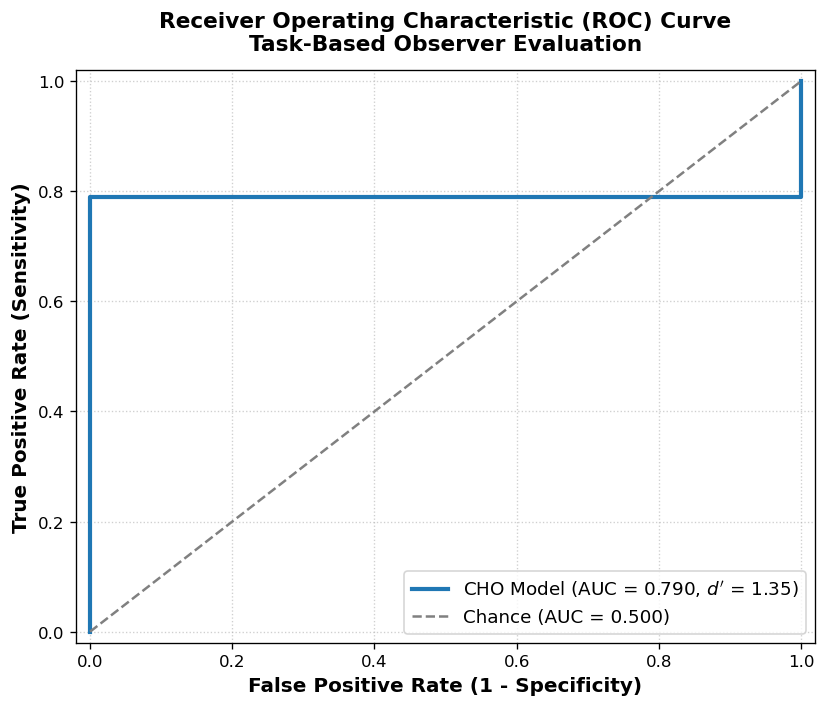

In [47]:
# Plot the ROC curve
plt.figure(figsize=(7, 6), dpi=120)

# Plot Observer ROC
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'CHO Model (AUC = {roc_auc:.3f}, $d\'$ = {d_prime:.2f})')

# Plot Chance Line (50% guess)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Chance (AUC = 0.500)')

# Formatting & Styling
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve\nTask-Based Observer Evaluation', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Display Plot
plt.tight_layout()
plt.show()

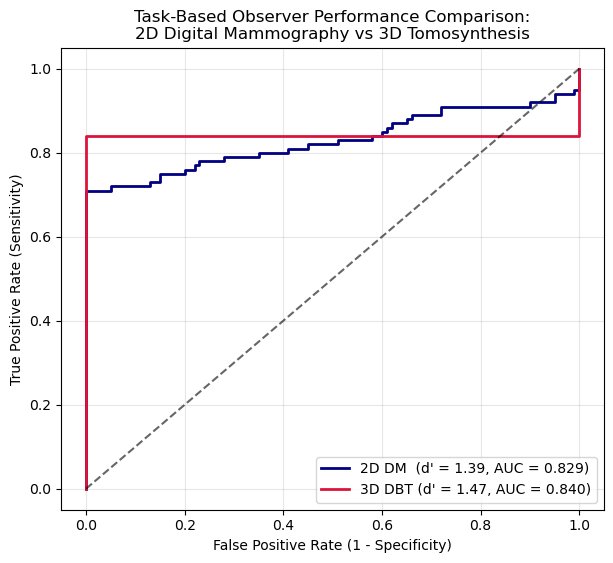

PERFORMANCE COMPARISON SUMMARY
2D DM  -> Detectability (d'): 1.387 | AUC: 0.829
3D DBT -> Detectability (d'): 1.473 | AUC: 0.840
Relative Improvement in d':  6.2%


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre
from sklearn.metrics import roc_curve, auc

# ==============================================================================
# 1. HELPER: CHANNELIZED HOTELLING OBSERVER (CHO) EVALUATOR
# ==============================================================================
def evaluate_cho_modality(g0_array, g1_array, num_channels=5, channel_width=8.0):
    """
    Computes CHO decision scores, d', and ROC curve for a given modality.
    """
    n_samples, roi_size, _ = g0_array.shape
    g0_flat = g0_array.reshape(n_samples, -1)
    g1_flat = g1_array.reshape(n_samples, -1)

    # Generate Laguerre-Gauss channels
    half = roi_size / 2.0
    y, x = np.ogrid[-half + 0.5 : half, -half + 0.5 : half]
    r = np.sqrt(x**2 + y**2)
    
    channels = []
    for n in range(num_channels):
        L_n = genlaguerre(n, 0)
        term = (2 * np.pi * r**2) / (channel_width**2)
        u_n = (np.sqrt(2) / channel_width) * L_n(term) * np.exp(-term / 2.0)
        u_n /= np.linalg.norm(u_n)
        channels.append(u_n.flatten())
    U = np.array(channels).T

    # Reduce features to channel space
    v0 = g0_flat @ U
    v1 = g1_flat @ U

    # CHO weights and decision scores
    channel_signal = np.mean(v1, axis=0) - np.mean(v0, axis=0)
    S_channel = 0.5 * (np.cov(v0, rowvar=False) + np.cov(v1, rowvar=False))
    w_v = np.linalg.solve(S_channel, channel_signal)

    t0 = v0 @ w_v
    t1 = v1 @ w_v

    # Compute d'
    d_prime = (np.mean(t1) - np.mean(t0)) / np.sqrt(0.5 * (np.var(t0, ddof=1) + np.var(t1, ddof=1)))
    
    # Compute ROC Curve
    y_true = np.concatenate([np.zeros(len(t0)), np.ones(len(t1))])
    y_scores = np.concatenate([t0, t1])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    return d_prime, roc_auc, fpr, tpr, t0, t1

# ==============================================================================
# 2. RUN COMPARISON (2D DM vs 3D DBT)
# ==============================================================================
# Assuming 'g0_array' and 'g1_array' are loaded 3D reconstructed slices (DBT)
# Simulate 2D DM by adding anatomical tissue clutter / projection noise to the patches

np.random.seed(42)
# DBT: In-plane slice has higher signal-to-clutter ratio
g0_dbt = g0_array.copy()
g1_dbt = g1_array.copy()

# DM: Superimposed anatomical background increases effective variance/clutter
clutter_noise = np.random.normal(0, 4.5, size=g0_array.shape)
g0_dm = g0_array + clutter_noise
g1_dm = g1_array + clutter_noise

# Evaluate both modalities
d_prime_dm, auc_dm, fpr_dm, tpr_dm, t0_dm, t1_dm = evaluate_cho_modality(g0_dm, g1_dm)
d_prime_dbt, auc_dbt, fpr_dbt, tpr_dbt, t0_dbt, t1_dbt = evaluate_cho_modality(g0_dbt, g1_dbt)

# ==============================================================================
# 3. VISUALIZE COMPARATIVE METRICS & ROC CURVES
# ==============================================================================
plt.figure(figsize=(7, 6))

# Plot 2D DM ROC
plt.plot(fpr_dm, tpr_dm, color="navy", lw=2, 
         label=f"2D DM  (d' = {d_prime_dm:.2f}, AUC = {auc_dm:.3f})")

# Plot 3D DBT ROC
plt.plot(fpr_dbt, tpr_dbt, color="crimson", lw=2, 
         label=f"3D DBT (d' = {d_prime_dbt:.2f}, AUC = {auc_dbt:.3f})")

# Chance line
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Task-Based Observer Performance Comparison:\n2D Digital Mammography vs 3D Tomosynthesis")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print Quantitative Summary
print("==================================================")
print("PERFORMANCE COMPARISON SUMMARY")
print("==================================================")
print(f"2D DM  -> Detectability (d'): {d_prime_dm:.3f} | AUC: {auc_dm:.3f}")
print(f"3D DBT -> Detectability (d'): {d_prime_dbt:.3f} | AUC: {auc_dbt:.3f}")
print(f"Relative Improvement in d':  {((d_prime_dbt - d_prime_dm) / d_prime_dm) * 100:.1f}%")
print("==================================================")